In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,roc_curve, auc,
    classification_report, roc_auc_score
)
from lime.lime_tabular import LimeTabularExplainer

# TUNING 1

KNN Model Performance for first run
- Train Accuracy: 0.55
- Validation Accuracy: 0.41
- Test Accuracy: 0.40

Review what have done on data in preprocessing
- Resize (300,300) to (128,128)
- Normalized pixel values to [0,1]
- Data augmented(flip, crop, color jitter)

### Analysis on what is done and what should be done better for model

- Since KNN doesn't generalize patters like CNN, it is not better to augment data.
- Reduce dimensionality using PCA, before that converting images to grayscale (reduces dimensions from 3×128×128 to 1×128×128).
- Flatten images from (128,128) to (128*128, ) and can apply PCA to reduce dimensionality further around 100 components.

#### By running KNN with PCA might improve speed and accuracy.

- it would be better if we reduce the datasize <10K. because KNN works better on low dataset.

In [5]:
def load_images_flattened(folder_path, grayscale=True):
    images = []
    photo_ids = []

    for filename in sorted(os.listdir(folder_path)):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(folder_path, filename)
            img = Image.open(path)

            if grayscale:
                img = img.convert('L')

            img_array = np.asarray(img, dtype=np.float32)
            img_flat = img_array.flatten()

            images.append(img_flat)

            photo_id = os.path.splitext(filename)[0]
            photo_ids.append(photo_id)

    print(f"Loaded {len(images)} images from {folder_path}")
    return np.array(images), photo_ids

In [6]:
train_df = pd.read_csv("train_metadata.csv")
print(train_df.columns)

Index(['photo_id', 'business_id', 'caption', 'label'], dtype='object')


In [7]:
def align_images_with_labels(X, photo_ids, metadata_path):
    df = pd.read_csv(metadata_path)
    df = df[df['photo_id'].astype(str).isin(photo_ids)]
    df = df.set_index('photo_id').loc[photo_ids].reset_index()
    y = df["label"].values
    return X, y

In [8]:
# Load images and corresponding photo_ids
X_train, train_photo_ids = load_images_flattened("split_photos/train")

# Load metadata
train_df = pd.read_csv("train_metadata.csv")

# Keep only rows where photo_id is in the loaded images
train_df = train_df[train_df['photo_id'].astype(str).isin(train_photo_ids)]

# Sort train_df to match the order of images
train_df = train_df.set_index('photo_id').loc[train_photo_ids].reset_index()

# Extract labels
y_train = train_df["label"].values

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# Load validation set
X_val_raw, val_photo_ids = load_images_flattened("split_photos/val")
X_val, y_val = align_images_with_labels(X_val_raw, val_photo_ids, "val_metadata.csv")

# Load test set
X_test_raw, test_photo_ids = load_images_flattened("split_photos/test")
X_test, y_test = align_images_with_labels(X_test_raw, test_photo_ids, "test_metadata.csv")

print(f"X_val shape = {X_val.shape}, y_val shape = {y_val.shape}")
print(f"X_test shape = {X_test.shape}, y_test shape = {y_test.shape}")


Loaded 17192 images from split_photos/train
X_train shape: (17192, 16384), y_train shape: (17192,)
Loaded 2146 images from split_photos/val
Loaded 2149 images from split_photos/test
X_val shape = (2146, 16384), y_val shape = (2146,)
X_test shape = (2149, 16384), y_test shape = (2149,)


### Since 128 × 128 = 16,384, each image is a 1D vector of length 16,384

## Apply PCA

In [11]:
# Reduce to 200 dimensions (randomly choosen)
pca = PCA(n_components=200, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# Transform val and test using the same PCA
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)


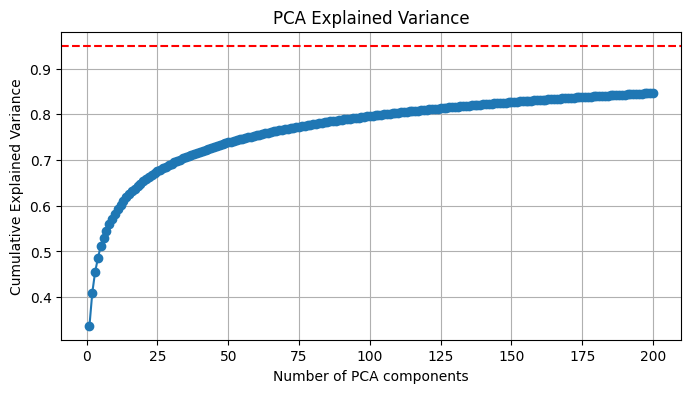

In [12]:
#  Check variance to choose how many PCA components to keep
explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(explained)+1), explained, marker='o')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(0.95, color='red', linestyle='--')
plt.title('PCA Explained Variance')
plt.show()


At ~100 components, it capturing around 75–80% of the variance, so it balance dimensionality reduction and reasonable amount of retained variance, which can be a smooth tradeoff between size and performance.

## Apply PCA with 100 Components

In [15]:
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

## Train KNN on PCA-Reduced Data

In [17]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_pca, y_train)

# Predict on validation and test
y_train_pred = knn.predict(X_train_pca)
y_val_pred = knn.predict(X_val_pca)
y_test_pred = knn.predict(X_test_pca)

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


Training Accuracy: 0.6216845044206608
Validation Accuracy: 0.4506057781919851
Test Accuracy: 0.4383434155421126


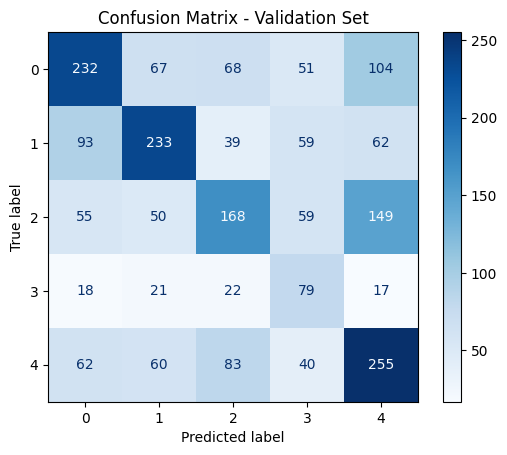

In [18]:
# Confusion matrix for validation set
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Validation Set")
plt.show()

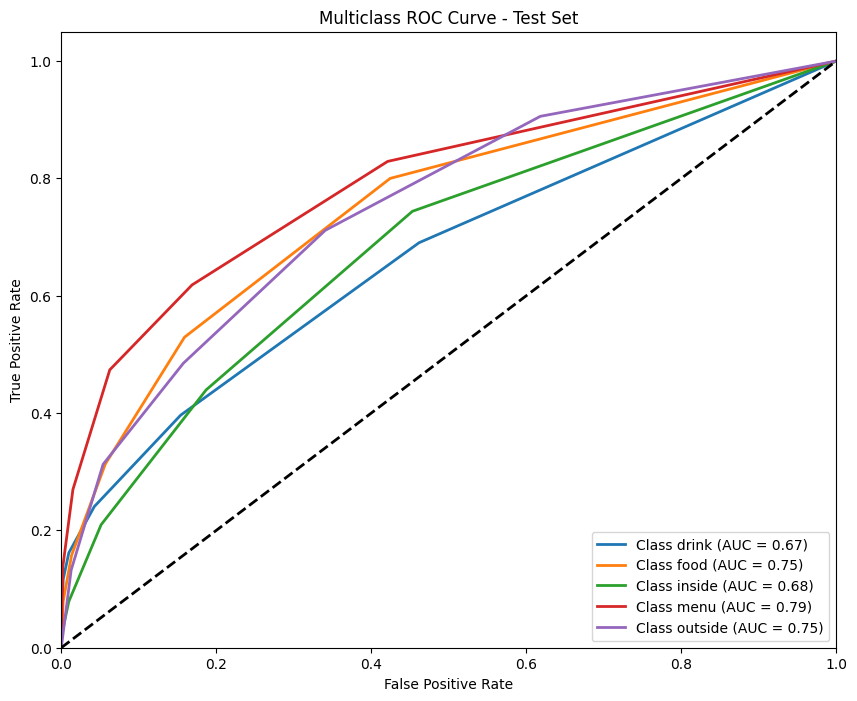

In [19]:
classes = np.unique(y_test)
n_classes = len(classes)

# Binarize y_val (true labels)
y_test_bin = label_binarize(y_test, classes=classes)

y_test_prob = knn.predict_proba(X_test_pca) 

plt.figure(figsize=(10,8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.show()

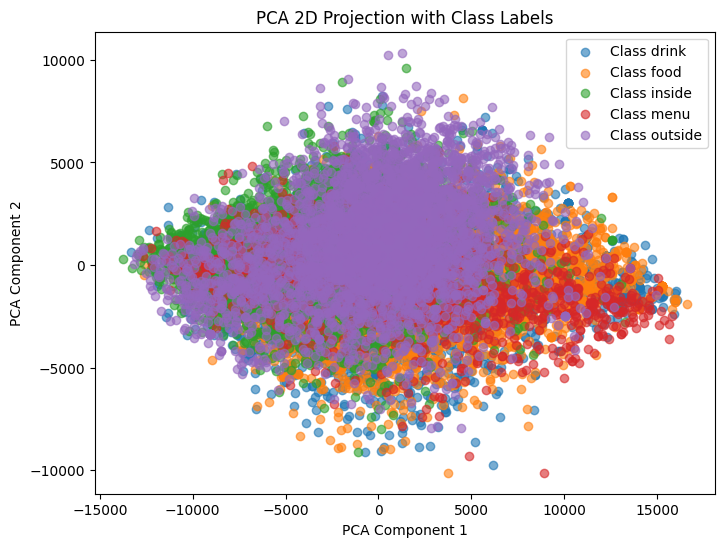

In [20]:

# Reduce to 2 PCA components for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(8,6))
for class_label in np.unique(y_train):
    plt.scatter(
        X_train_2d[y_train == class_label, 0],
        X_train_2d[y_train == class_label, 1],
        label=f'Class {class_label}', alpha=0.6
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA 2D Projection with Class Labels')
plt.legend()
plt.show()


- Overfitting
- May be the classes are not easily sepearable in PCA
- Or tuning KNN hyperparameters might help

# TUNING 2

- Tune KNN Hyperparameters

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=3)
grid.fit(X_train_pca, y_train)

print("Best Params:", grid.best_params_)
print("Best Cross-Val Score:", grid.best_score_)


Best Params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Best Cross-Val Score: 0.4642274865506468


In [24]:
val_acc = grid.best_estimator_.score(X_val_pca, y_val)
test_acc = grid.best_estimator_.score(X_test_pca, y_test)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Validation Accuracy: 0.4604
Test Accuracy: 0.4630


## Very slight improvement on both test and validation accuracy
- check if there is any class imbalance

In [26]:
from sklearn.metrics import classification_report

y_val_pred = grid.best_estimator_.predict(X_val_pca)
y_test_pred = grid.best_estimator_.predict(X_test_pca)

print("Validation Report:\n", classification_report(y_val, y_val_pred))
print("Test Report:\n", classification_report(y_test, y_test_pred))


Validation Report:
               precision    recall  f1-score   support

       drink       0.61      0.38      0.47       522
        food       0.59      0.50      0.54       486
      inside       0.44      0.36      0.39       481
        menu       0.29      0.51      0.37       157
     outside       0.40      0.59      0.48       500

    accuracy                           0.46      2146
   macro avg       0.46      0.47      0.45      2146
weighted avg       0.49      0.46      0.46      2146

Test Report:
               precision    recall  f1-score   support

       drink       0.54      0.34      0.42       507
        food       0.59      0.46      0.51       495
      inside       0.49      0.37      0.42       496
        menu       0.29      0.57      0.38       152
     outside       0.42      0.66      0.51       499

    accuracy                           0.46      2149
   macro avg       0.47      0.48      0.45      2149
weighted avg       0.50      0.46      0.46

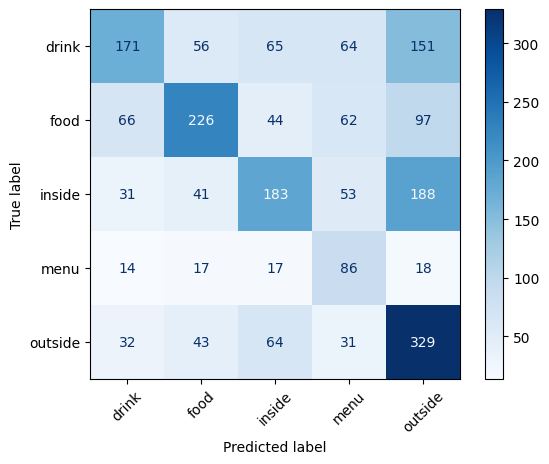

In [27]:
# class labels in order
class_labels = sorted(pd.Series(y_train).unique())

cm = confusion_matrix(y_test, y_test_pred, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', xticks_rotation=45)


- food performs best among classes
- inside class is badly confused with outside class
- drink is highly confused with other labels and mostly with outside
- outside performs well among all classes

# TUNING 3

In [30]:
# Class counts
print("Train class distribution:\n", pd.Series(y_train).value_counts())
print("\nValidation class distribution:\n", pd.Series(y_val).value_counts())
print("\nTest class distribution:\n", pd.Series(y_test).value_counts())


Train class distribution:
 inside     4023
food       4006
outside    4001
drink      3971
menu       1191
Name: count, dtype: int64

Validation class distribution:
 drink      522
outside    500
food       486
inside     481
menu       157
Name: count, dtype: int64

Test class distribution:
 drink      507
outside    499
inside     496
food       495
menu       152
Name: count, dtype: int64


## No noticable imbalance in classes (except menu)

In [32]:
pd.Series(y_train).value_counts()

inside     4023
food       4006
outside    4001
drink      3971
menu       1191
Name: count, dtype: int64

In [33]:
from sklearn.utils import resample

# Combine PCA'd features and labels into a DataFrame
df_train = pd.DataFrame(X_train_pca)  # X_train_pca from your original PCA
df_train['label'] = y_train

# Find minimum class size (menu has 1191)
min_samples = df_train['label'].value_counts().min()

# Subsample each class to match smallest class
df_balanced = pd.concat([
    resample(sub_df, replace=False, n_samples=min_samples, random_state=42)
    for _, sub_df in df_train.groupby('label')
])

# Split back into X and y
X_train_bal = df_balanced.drop('label', axis=1).values
y_train_bal = df_balanced['label'].values

print(f"Balanced training shape: {X_train_bal.shape}")
print(pd.Series(y_train_bal).value_counts())


Balanced training shape: (5955, 100)
drink      1191
food       1191
inside     1191
menu       1191
outside    1191
Name: count, dtype: int64


In [34]:
param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'cosine']
}

In [35]:
knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid.fit(X_train_bal, y_train_bal)

print("Best Params:", grid.best_params_)
print("Best Cross-Val Score:", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'metric': 'cosine', 'n_neighbors': 15, 'weights': 'distance'}
Best Cross-Val Score: 0.46364399664147776


In [36]:
# Best model from GridSearchCV on balanced data
best_knn = grid.best_estimator_

# Predict on original val and test sets (PCA transformed)
y_val_pred = best_knn.predict(X_val_pca)
y_test_pred = best_knn.predict(X_test_pca)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


Validation Accuracy: 0.43056849953401677
Test Accuracy: 0.4290367612843183


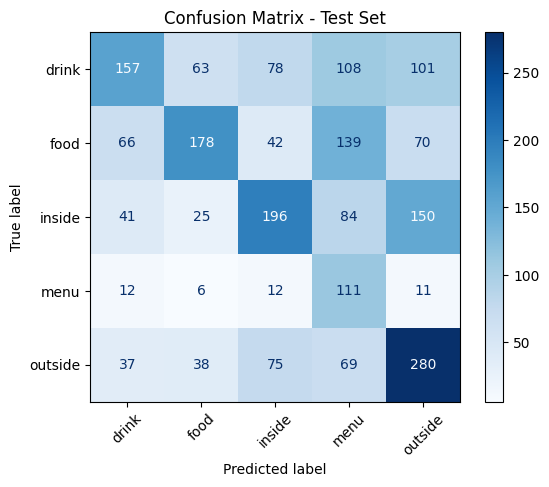

In [37]:
labels_sorted = sorted(np.unique(y_train_bal))
cm = confusion_matrix(y_test, y_test_pred, labels=labels_sorted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()

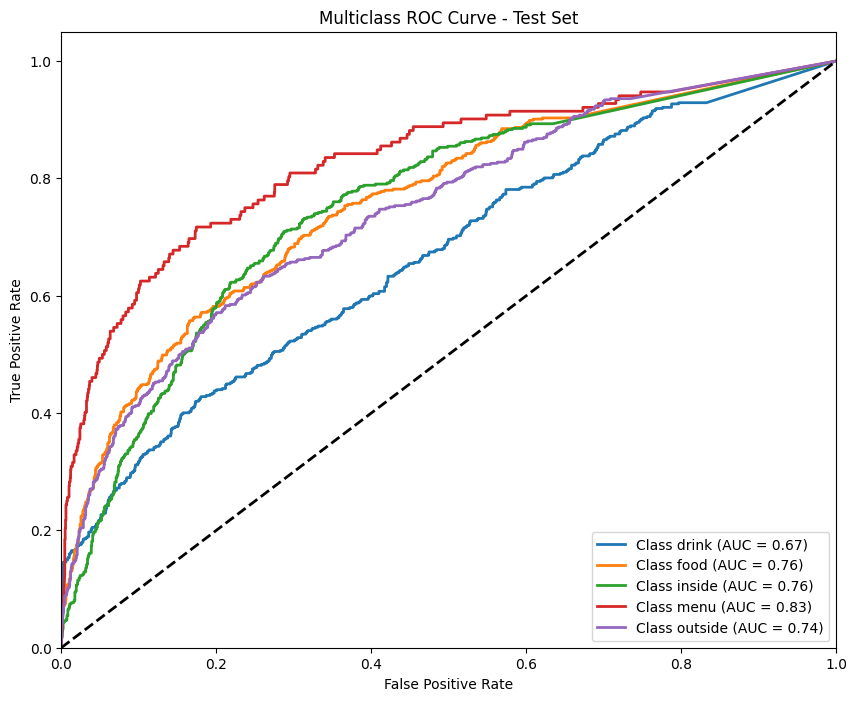

In [38]:
# Use the best estimator from grid search to predict probabilities on test set
best_knn = grid.best_estimator_
y_test_prob = best_knn.predict_proba(X_test_pca)  # shape: (n_samples, n_classes)

classes = np.unique(y_train_bal)  # classes from training
y_test_bin = label_binarize(y_test, classes=classes)  # binarize test labels
n_classes = len(classes)

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.show()

### Many images having food,drink, menu leading to ambiguity.
- PCA+KNN: PCA removing dimensions without considering class seperability and KNN lacks feature learning.
- key features like textures, shapes, and objects are preserved by doing the preprocessing like greyscale, flattening unlike raw images

## Tuned model have improved a bit 
- class drink 0.67 -> 0.67
- class food 0.75 -> 0.76
- class inside 0.68 -> 0.76
- class menu 0.79 -> 0.83
- class outside 0.72 -> 0.74

## Overall, the tuning clearly improved generalization and classification performance on the test set.

# TUNING 4
- indentifying important features by lime
- standardizind data before doing PCA
- Reduce components to 50 (after checking variance plot above)
- Find best K value for Model

In [41]:
from lime.lime_tabular import LimeTabularExplainer

# Feature names based on PCA components
feature_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

# get sorted class names from unique labels (adjust if you have a label encoder)
class_names = np.unique(y_train_bal).astype(str)

# Create the LIME explainer using balanced training data (PCA features)
explainer = LimeTabularExplainer(
    training_data=X_train_bal,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

# Select a test sample to explain
sample_index = 0
sample_data = X_test_pca[sample_index]
sample_label = y_test[sample_index]

# Explain the prediction for the chosen sample
exp = explainer.explain_instance(
    data_row=sample_data,
    predict_fn=best_knn.predict_proba,
    num_features=10
)

# Display explanation in notebook
exp.show_in_notebook(show_table=True)


- outside is most likely to be predicted than other classes
- The model predicts the sample is "outside", not "food", with only 12% probability for food.
- principal components PC1 pushed prediction towards food and PC3 away from food(more influence)
- KNN is struggling with 100 components, reducing it to 50 PCs by analysing the above variance plot which is capturing 75% of variance.

## Sandardizing for PCA

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## PCA with 50 components

In [80]:
# Reduce to 50 dimensions (randomly choosen)
pca = PCA(n_components=50, random_state=42)
X_train_pca2 = pca.fit_transform(X_train_scaled)

# Transform val and test using the same PCA
X_val_pca2 = pca.transform(X_val_scaled)
X_test_pca2 = pca.transform(X_test_scaled)

## Finding best K

In [82]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {'n_neighbors': list(range(1, 21))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_pca2, y_train)

print("Best K:", grid.best_params_)


Best K: {'n_neighbors': 19}


In [84]:
knn = KNeighborsClassifier(n_neighbors=19, n_jobs=-1)
knn.fit(X_train_pca2, y_train)

# Predict on validation and test
y_train_pred2 = knn.predict(X_train_pca2)
y_val_pred2 = knn.predict(X_val_pca2)
y_test_pred2 = knn.predict(X_test_pca2)

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred2))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred2))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred2))


Training Accuracy: 0.5396114471847371
Validation Accuracy: 0.4739049394221808
Test Accuracy: 0.470451372731503


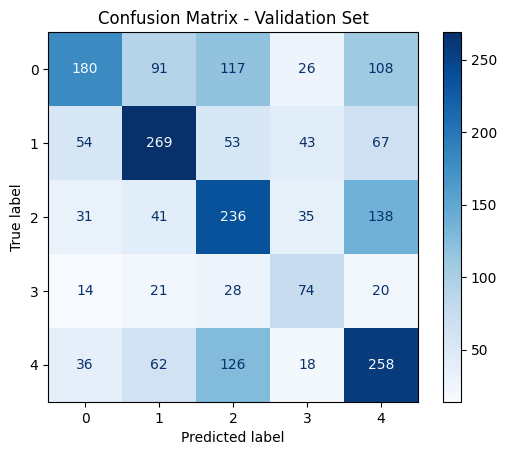

In [86]:
# Confusion matrix for validation set
cm = confusion_matrix(y_val, y_val_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Validation Set")
plt.show()

## 0-drink, 1-food, 2-inside, 3-menu, 4-outside

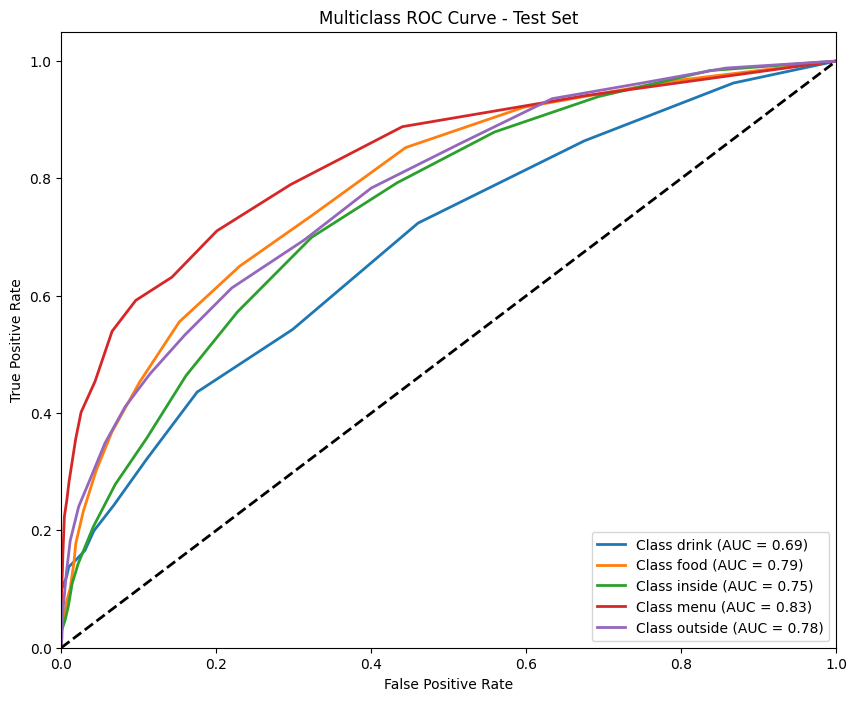

In [90]:
classes = np.unique(y_test)
n_classes = len(classes)

# Binarize y_val (true labels)
y_test_bin2 = label_binarize(y_test, classes=classes)

y_test_prob2 = knn.predict_proba(X_test_pca2) 

plt.figure(figsize=(10,8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin2[:, i], y_test_prob2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.show()

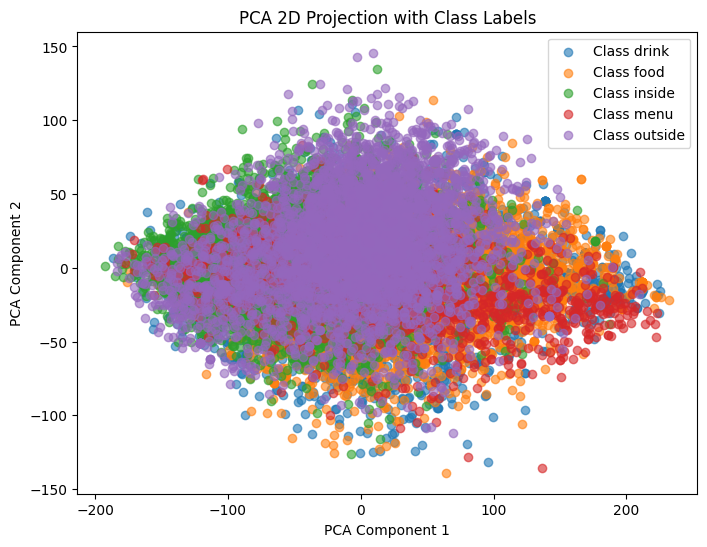

In [92]:

# Reduce to 2 PCA components for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_pca2)

plt.figure(figsize=(8,6))
for class_label in np.unique(y_train):
    plt.scatter(
        X_train_2d[y_train == class_label, 0],
        X_train_2d[y_train == class_label, 1],
        label=f'Class {class_label}', alpha=0.6
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA 2D Projection with Class Labels')
plt.legend()
plt.show()


# Summary
1. Resize image(done in preprocessing)
2. Normalize (done in preprocessing)
3. split into Train/Val/Test (done in preprocessing)
4. Convert to Grayscale to reduce dimesions(3*128*128 -> 1*128*128)
5. Flatten to 1D vector (for PCA)
6. PCA (fit on train only)
7. KNN (train on PCA output) tried with 100 components, 50 components after analysing variance and performance tradeoff
8. Hyperparameter tuning
9. Class Imbalance
10. Lime with classifier b/w food vs not food.
11. standardized the data for PCA, Find best K value and run KNN as final tuning.
## No overfitting
## Improved accuracy 
-from Train-53, test-40 -> train 62, test-43 -> Train-62, test-46 -> Train-54 ,Test-47
## Noticable Class balance in predictions
## Improved AUC scores for each class
- class drink 0.67 -> 0.67 -> 0.69
- class food 0.75 -> 0.76 -> 0.79
- class inside 0.68 -> 0.76 -> 0.75
- class menu 0.79 -> 0.83 -> 0.83
- class outside 0.72 -> 0.74 -> 0.78

# CNN works better for this dataset
- It learns complex, high-level features from data especially for image data
- KNN only compare raw vectors without learning.

import pickle
KNN_model = KNeighborsClassifier()

# Save the model to a file
with open("KNN.pkl", "wb") as f:
    pickle.dump(KNN_model, f)

print("Model saved as KNN.pkl")
